# Handling Cloud-Optimised Geotiff overviews <img align="right" src="../Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with the `DEA Sandbox` environment
* **Products used:** 
    - [ga_ls_landcover_class_cyear_3](https://explorer.dea.ga.gov.au/ga_ls_landcover_class_cyear_3);
    - [Landcover continental COG mosaics](https://data.dea.ga.gov.au/?prefix=derivative/ga_ls_landcover_class_cyear_3/2-0-0/continental_mosaics/)
* **Prerequisites:** It is recommended to first read the notebook [Generating_COG_mosaics](./Generating_COG_mosaics.ipynb)

## Background

Some DEA products are provided as continental-scale mosaics in the form of [Cloud Optimised GeoTIFFs (COGs)](https://knowledge.dea.ga.gov.au/guides/continental-cogs-geotiff-mosaics/).  These mosaics enable the streaming of DEA data via GIS software and are accompanied by Virtual Raster (VRT) files, which are lightweight wrappers that automatically provide visualisation styling when streaming the data.

COGs include overviews (or pyramids) that approximate the raw data array at a coarser spatial resolution by applying a resampling algorithm such as `NEAREST`, `BILINEAR`, or `MODE`. This allows data to be streamed at a continental scale much faster than if the entire array were to be loaded at native resolution.

While the main advantage of COGs lies in their use within GIS software, they can also be accessed programmatically using languages such as Python, with packages like `rioxarray` or `gdal`.

Although using the native resolution of the data array is recommended, it is also possible to access the coarser overviews to reduce computational demand when working on smaller machines, or when the data resolution needs to match that of another, coarser resolution product.

## Description
This notebook explores how to perform the following actions:
* Define a region of interest (ROI)
* Access a mosaic Cloud-Optimised GeoTIFFs (COGs) from the DEA S3 repository
* Load the data for our ROI using different overviews and observe the differences in Land Cover classes' extent

***

## Getting started

### Load packages
Import the Python packages needed for this notebook.

In [1]:
import sys
import rioxarray
import numpy as np
from osgeo import gdal
from odc.geo.xr import crop
import matplotlib.pyplot as plt
from odc.geo import BoundingBox

sys.path.insert(1, "../Tools/")
from dea_tools.plotting import display_map
from dea_tools.landcover import lc_colourmap, get_colour_scheme, make_colourbar

## Analysis Parameters

In this notebook, we will use [DEA Land Cover](https://knowledge.dea.ga.gov.au/data/product/dea-land-cover-landsat/) Level 4 as an example, and the analysis parameters below reflect this. You can see which other products are distributed as mosaics here: [Continental Cloud-Optimised GeoTIFF Mosaics](https://knowledge.dea.ga.gov.au/guides/continental-cogs-geotiff-mosaics/).

* `lat`, `lon`: The central latitude and longitude to analyse. In this example we'll the region around Canberra
* `buffer`: The number of square degrees to load around the central latitude and longitude. For reasonable loading times, set this as 0.1 or lower.
* `product`: The name of the DEA producta to load, in the example we will use DEA Landcover
* `version`: The latest version of DEA Landcover is `'2-0-0'`
* `level`: DEA Landcover has a two measurements, `'level3'` and `'level4'` 
* `year`: The year of interest to load. DEA Landcover is an annual product starting in 1988



In [2]:
# Coordinates for Canberra region
lat, lon = -35.325, 149.0918
buffer = 0.5

# Define variables needed to obtain the DEA Land Cover Level 4 data. Currently, the most recent version is 2-0-0.
product = 'ga_ls_landcover_class_cyear_3'
version = '2-0-0'
level = 'level3'

# Set year of interest
year = 2024

### View your study area

In the default example the bound box covers the region around Canberra.

In [3]:
bbox = BoundingBox(
    left= lon - buffer,
    bottom=lat - buffer,
    right=lon + buffer,
    top=lat + buffer,
    crs="EPSG:4326"
)

bbox.explore()

## Load data from the continental mosaic and crop it to the ROI
We will read the COG continental mosaic from the [DEA S3 repository](https://data.dea.ga.gov.au/?prefix=derivative/ga_ls_landcover_class_cyear_3/2-0-0/continental_mosaics/) and see how many overviews are included in the file.

In [4]:
# URL to DEA continental mosaics
cog_url = f'https://data.dea.ga.gov.au/derivative/{product}/{version}/continental_mosaics/{year}--P1Y/{product}_mosaic_{year}--P1Y_{level}.tif'

In [5]:
# We will use gdal to quickly gather information on the overviews contained in the COG
# let's add the vsicurl driver to facilitate reading the file with GDAL
cog = gdal.Open(f'/vsicurl/{cog_url}', gdal.GA_ReadOnly) 

# We select the first and only band in the mosaic
band = cog.GetRasterBand(1) 

overview_count = band.GetOverviewCount()
print(f'The mosaic of {product} - {year}, contains {overview_count} overviews\n')
for i in range(overview_count):
    ov = band.GetOverview(i)
    print(f"Overview {i}: size = {ov.XSize} x {ov.YSize} pixels")

The mosaic of ga_ls_landcover_class_cyear_3 - 2024, contains 7 overviews

Overview 0: size = 68800 x 64000 pixels
Overview 1: size = 34400 x 32000 pixels
Overview 2: size = 17200 x 16000 pixels
Overview 3: size = 8600 x 8000 pixels
Overview 4: size = 4300 x 4000 pixels
Overview 5: size = 2150 x 2000 pixels
Overview 6: size = 1075 x 1000 pixels


/env/lib/python3.10/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


We observed that there are seven overviews, each halving the size of the array at every level. Because we are interested in a large region, we will load the data at a medium overview level using the argument `overview_level` in `rioxarray.open_rasterio()`.

For categorical data such as DEA Land Cover, the overviews were generated using the `mode` algorithm. This means that pixels at the native resolution representing uncommon or sparsely distributed classes might be lost during resampling.

In [6]:
# Define the overview level of interest
overview_level = 3

In [7]:
# Read a specific overview of the COG with rioxarray and check what the CRS of the file is
cog_array = rioxarray.open_rasterio(cog_url, overview_level=overview_level)
cog_crs = cog_array.rio.crs
print(f'The CRS of the COG is {cog_crs}')

The CRS of the COG is EPSG:3577


Now we can crop the array to our ROI.

In [8]:
roi_geom = bbox.boundary().convex_hull

cog_roi = crop(cog_array, roi_geom)
print(f'The CRS of the cropped COG is {cog_roi.rio.crs}')
print(f'The shape of the array is {cog_roi.shape}')

The CRS of the cropped COG is EPSG:3577
The shape of the array is (1, 256, 219)


Let's quickly visualise the extent of the final array.

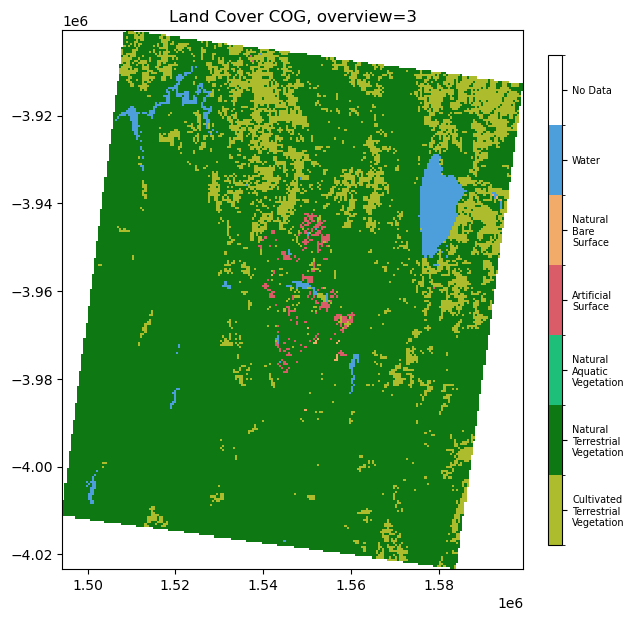

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7), sharey=True)

# Trim no-data off the colormap
colour_scheme = get_colour_scheme(level)
cmap, norm = lc_colourmap(colour_scheme)
im = cog_roi.plot(cmap=cmap, norm=norm, ax=ax, add_labels=False, add_colorbar=False)
ax.set_title(f"Land Cover COG, overview={overview_level}", fontsize=12);
make_colourbar(fig, ax, measurement=level, labelsize=7, horizontal=False)

## Analyse the data
Now we can include the data in any workflow that involves data arrays. Here we will perform a simple value count as an example and observe the extent of each land cover class in our bbox

You can see the name corresponding to each class value in the [DEA Knowledge Hub](https://knowledge.dea.ga.gov.au/data/product/dea-land-cover-landsat/?tab=description#level-4).

In [10]:
# First we convert our array to a 1D vector and mask out NaN values
data_1d = cog_roi.values.flatten()
data_1d = data_1d[~np.isnan(data_1d)]

In [11]:
# Let's count the number of pixels in each class
classes, counts = np.unique(data_1d, return_counts=True)

At the native resolution, each pixel covers 30 m x 30 m. Because each overview level halves the array's width and height, the pixel size increases with each overview level, calculated as:

$$
\text{Spatial Resolution} [m] = 30 \times 2^{\text{overview\_level}}
$$

Where, `overview_level` corresponds to the Python index of the overviews (which starts from 0 for the raw data array).


In [12]:
# Define the pixel size of the selected overview
pixel_size_m = 30 * (2 ** overview_level)

# Calculate the area of one pixel
pixel_area_m2 = pixel_size_m ** 2           
pixel_area_km2 = pixel_area_m2 / 1e6   

# Calculate the total area of each class
area_km2 = counts * pixel_area_km2

We will visualise the areal extent of the Land Cover classes with a bar chart.

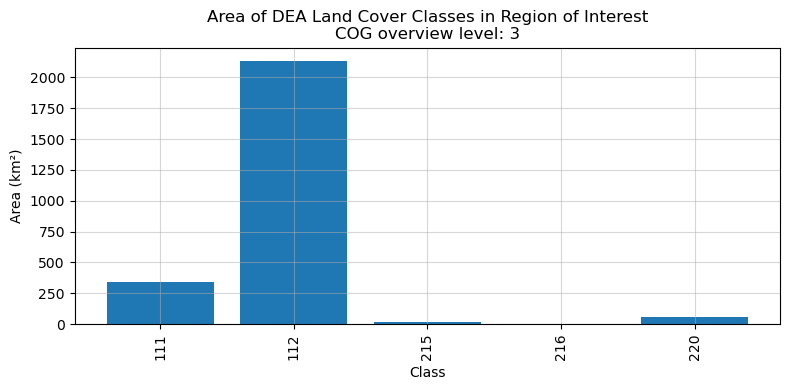

In [13]:
x_pos = np.arange(len(classes)) # positions of x axis ticks

plt.figure(figsize=(8,4))

# Plot area in km² per class
plt.bar(x_pos, area_km2)

plt.xlabel('Class')
plt.ylabel('Area (km²)')
plt.title(f'Area of DEA Land Cover Classes in Region of Interest\nCOG overview level: {overview_level}')

plt.xticks(x_pos, [int(c) for c in classes], rotation=90)
plt.grid(alpha=0.5)
plt.tight_layout();

## Compare different overviews

In this final section, we will quickly explore the differences between overviews to raise awareness on the caveats associated with using a resampled product, particularly when representing categorical data.

### Load two different levels

In [14]:
# Get the data in the native resolution (30 m) and crop it to our ROI
fine_overview_level = 0
fine_cog = rioxarray.open_rasterio(cog_url, overview_level=fine_overview_level)
fine_cog = crop(fine_cog, roi_geom)

In [15]:
# Repeat for the highest overview 
coarse_overview_level = 3
coarse_cog = rioxarray.open_rasterio(cog_url, overview_level=coarse_overview_level)
coarse_cog= crop(coarse_cog, roi_geom)

### Plot side by side

We can observe how resampling to a much coarser resolution has changed the pixel values and the look of the landscape.

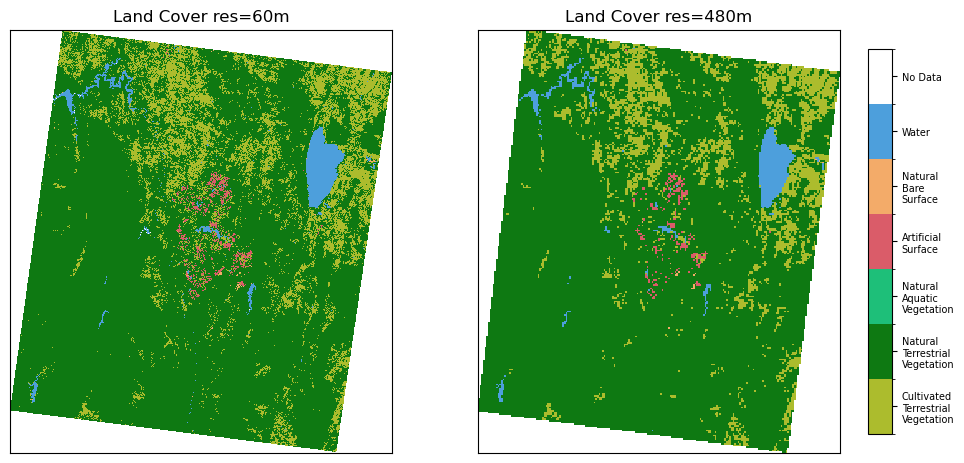

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)

# Trim no-data off the colormap
colour_scheme = get_colour_scheme(level)
cmap, norm = lc_colourmap(colour_scheme)
im = fine_cog.plot(cmap=cmap, norm=norm, ax=ax[0], add_labels=False, add_colorbar=False)
ax[0].set_title(f"Land Cover res={int(fine_cog.rio.resolution()[0])}m", fontsize=12);

im = coarse_cog.plot(cmap=cmap, norm=norm, ax=ax[1], add_labels=False, add_colorbar=False)
ax[1].set_title(f"Land Cover res={int(coarse_cog.rio.resolution()[0])}m", fontsize=12);
make_colourbar(fig, ax[1], measurement=level, labelsize=7, horizontal=False)

for a in ax.ravel():
    a.axes.get_xaxis().set_ticks([])
    a.axes.get_yaxis().set_ticks([]);

### Find the area of each class

In [17]:
# Finest overview (30 m spatial resolution)
fine_data_1d = fine_cog.values.flatten()
fine_data_1d = fine_data_1d[~np.isnan(fine_data_1d)]

fine_classes, fine_counts = np.unique(fine_data_1d, return_counts=True)

fine_pixel_size = 30 * (2 ** fine_overview_level) # effectively this is 30 m for the overview level 0
fine_pixel_area_km2 = (fine_pixel_size ** 2) / 1e6

# Coarsest overview
coarse_data_1d = coarse_cog.values.flatten()
coarse_data_1d = coarse_data_1d[~np.isnan(coarse_data_1d)]

coarse_classes, coarse_counts = np.unique(coarse_data_1d, return_counts=True)

coarse_pixel_size = 30 * (2 ** coarse_overview_level)
coarse_pixel_area_km2 = (coarse_pixel_size ** 2) / 1e6

Finally, by plotting the class extents of the two overviews side by side, we observe that the extent of some less common classes decreases at the coarser resolution, while the area of other more widespread classes increases.

### Plot the difference in class areas

Class area is expressed as _relative_ to the total class area in the fine resolution overiew (i.e. the 30m resolution dataset). This means all the values for the `Overview Level: 0` columns will be 1, while the coarse overviews will be either greater or smaller than 1 depending on how the area has changed following the resampling.

It's important to note that a high _relative_ change does not necessarily correspond to a substantial shift in _absolute_ extent. Rare or sparsely distributed classes with very small _absolute_ areas can show large _relative_ changes at coarser overviews, even though their overall contribution to the landscape remains minimal.

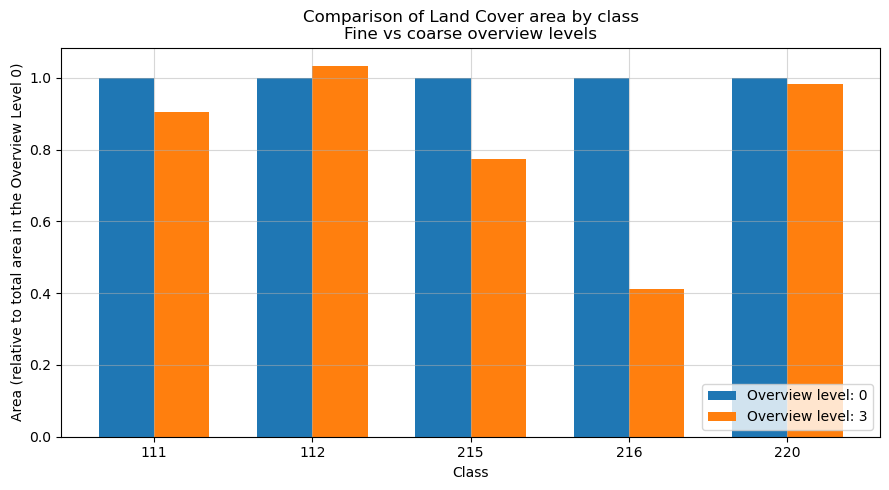

In [18]:
# Combine unique classes from fine and coarse overviews into a single sorted array
# Remove no-data counts
all_classes = np.union1d(fine_classes, coarse_classes)[0:-1]

# Create dictionaries to store counts by class
fine_dict = dict(zip(fine_classes, fine_counts))
coarse_dict = dict(zip(coarse_classes, coarse_counts))

# Align counts to all_classes. Use 0 if class not in one overview
fine_aligned_counts = np.array([fine_dict.get(c, 0) for c in all_classes])
coarse_aligned_counts = np.array([coarse_dict.get(c, 0) for c in all_classes])

# Convert counts to area (km2)
fine_aligned_area_km2 = fine_aligned_counts * fine_pixel_area_km2
coarse_aligned_area_km2 = coarse_aligned_counts * coarse_pixel_area_km2

# Normalise area to the fine resolution. This allows to visualise the relative change of the classes' extent
coarse_aligned_area_km2 = coarse_aligned_area_km2/fine_aligned_area_km2
fine_aligned_area_km2 = fine_aligned_area_km2/fine_aligned_area_km2

x_pos = np.arange(len(all_classes))
width = 0.35

# Plot bars side-by-side comparing fine and coarse overview areas
plt.figure(figsize=(9, 5))
plt.bar(
    x_pos - width / 2,  # -width/2 shifts bars to the left
    fine_aligned_area_km2,
    width,
    label=f"Overview level: {fine_overview_level}",
) 

plt.bar(
    x_pos + width / 2,
    coarse_aligned_area_km2,
    width,
    label=f"Overview level: {coarse_overview_level}",
) 

plt.xlabel("Class")
plt.ylabel("Area (relative to total area in the Overview Level 0)")
plt.title("Comparison of Land Cover area by class\nFine vs coarse overview levels")
plt.xticks(x_pos, [int(c) for c in all_classes])
plt.legend(loc='lower right')
plt.grid(alpha=0.5)
plt.tight_layout();

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** October 2025

## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->